# Unit 8 code companion: Categorical Outcomes

Rates with honest intervals, a chi-square you can compute by hand, Simpson's paradox reproduced from the real Berkeley data, and a classifier whose threshold is chosen by money instead of by habit.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. A percentage is an estimate too

Every rate on every dashboard has a standard error. Most dashboards do not show it.

In [2]:
for x, n in [(12, 300), (120, 3000), (2, 20), (0, 50)]:
    p = x/n
    lo, hi = proportion_confint(x, n, method="wilson")
    print(f"{x:>4}/{n:<5} = {p:6.2%}   95% CI [{lo:6.2%}, {hi:6.2%}]   width {hi-lo:6.2%}")

print("\nNote the last row: 0 out of 50 does NOT mean 'never'.")
print(f"The rule of three says the rate could plausibly be as high as 3/50 = {3/50:.1%}")

  12/300   =  4.00%   95% CI [ 2.30%,  6.86%]   width  4.56%
 120/3000  =  4.00%   95% CI [ 3.36%,  4.76%]   width  1.41%
   2/20    = 10.00%   95% CI [ 2.79%, 30.10%]   width 27.32%
   0/50    =  0.00%   95% CI [ 0.00%,  7.13%]   width  7.13%

Note the last row: 0 out of 50 does NOT mean 'never'.
The rule of three says the rate could plausibly be as high as 3/50 = 6.0%


## 2. The same difference, three ways

A campaign moves conversion from 2.0% to 2.4%. Watch how differently the same fact can be reported.

In [3]:
p1, p2 = 0.020, 0.024
odds = lambda p: p/(1-p)
print(f"absolute difference : {100*(p2-p1):+.1f} percentage points")
print(f"relative difference : {100*(p2/p1 - 1):+.0f}%")
print(f"odds ratio          : {odds(p2)/odds(p1):.2f}")
print("\nAll three are true. They will produce three different meetings.")

# And whether it is even distinguishable from noise:
for n in [500, 5_000, 50_000]:
    count1, count2 = int(p1*n), int(p2*n)
    stat, pval = proportions_ztest([count2, count1], [n, n])
    print(f"n = {n:>6} per arm: p-value = {pval:.3f}")

absolute difference : +0.4 percentage points
relative difference : +20%
odds ratio          : 1.20

All three are true. They will produce three different meetings.
n =    500 per arm: p-value = 0.666
n =   5000 per arm: p-value = 0.173
n =  50000 per arm: p-value = 0.000


The effect never changed. Only the sample size did. A '20% lift' is a headline, a p-value is a statement about sample size, and neither one tells you whether to ship.

## 3. Chi-square, computed by hand and then by library



In [4]:
credit = pd.read_csv("https://richardson.byu.edu/220/credit_risk.csv")
tab = pd.crosstab(credit["loan_intent"], credit["loan_status"])
print(tab, "\n")
print("default rate by purpose:")
print((tab[1]/(tab[0]+tab[1])).sort_values().round(3), "\n")

expected = np.outer(tab.sum(axis=1), tab.sum(axis=0)) / tab.values.sum()
chi2_hand = ((tab.values - expected)**2 / expected).sum()
dof_hand = (tab.shape[0]-1)*(tab.shape[1]-1)
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(f"by hand : chi2 = {chi2_hand:.2f}, df = {dof_hand}")
print(f"library : chi2 = {chi2:.2f}, df = {dof}, p = {p:.2e}")

resid = (tab.values - expected)/np.sqrt(expected)
print("\nstandardized residuals (which cells drive it):")
print(pd.DataFrame(resid, index=tab.index, columns=["repaid", "defaulted"]).round(2))

loan_status          0    1
loan_intent                
DEBTCONSOLIDATION  102  133
EDUCATION          200  125
HOMEIMPROVEMENT     72   88
MEDICAL            125  151
PERSONAL           130  108
VENTURE            147  119 

default rate by purpose:
loan_intent
EDUCATION            0.385
VENTURE              0.447
PERSONAL             0.454
MEDICAL              0.547
HOMEIMPROVEMENT      0.550
DEBTCONSOLIDATION    0.566
dtype: float64 

by hand : chi2 = 28.66, df = 5
library : chi2 = 28.66, df = 5, p = 2.70e-05

standardized residuals (which cells drive it):
                   repaid  defaulted
loan_intent                         
DEBTCONSOLIDATION   -1.78       1.84
EDUCATION            2.46      -2.54
HOMEIMPROVEMENT     -1.18       1.23
MEDICAL             -1.49       1.54
PERSONAL             0.62      -0.64
VENTURE              0.80      -0.83


The p-value says 'not independent.' The *residuals* say which purposes are unusual and in which direction, and the rate table says how big the difference is. Report all three. The p-value alone is the least informative of them.

## 4. Simpson's paradox, from the real 1973 Berkeley data



In [5]:
dept = ["A", "B", "C", "D", "E", "F"]
men_app = np.array([825, 560, 325, 417, 191, 373]); men_adm = np.array([512, 353, 120, 138, 53, 22])
wom_app = np.array([108,  25, 593, 375, 393, 341]); wom_adm = np.array([ 89,  17, 202, 131, 94, 24])

print(f"OVERALL: men {men_adm.sum()/men_app.sum():.1%} admitted, "
      f"women {wom_adm.sum()/wom_app.sum():.1%} admitted\n")
print(f"{'dept':>5} {'men rate':>10} {'women rate':>12} {'women favored?':>16} {'dept selectivity':>18}")
for i, d in enumerate(dept):
    mr, wr = men_adm[i]/men_app[i], wom_adm[i]/wom_app[i]
    sel = (men_adm[i]+wom_adm[i])/(men_app[i]+wom_app[i])
    print(f"{d:>5} {mr:>10.1%} {wr:>12.1%} {str(wr > mr):>16} {sel:>18.1%}")

print("\nWhere did women apply? Share of each department's applicants who were women:")
for i, d in enumerate(dept):
    share = wom_app[i]/(wom_app[i]+men_app[i])
    sel = (men_adm[i]+wom_adm[i])/(men_app[i]+wom_app[i])
    print(f"  dept {d}: {share:5.1%} women, and the department admits {sel:5.1%} of applicants")

OVERALL: men 44.5% admitted, women 30.4% admitted

 dept   men rate   women rate   women favored?   dept selectivity
    A      62.1%        82.4%             True              64.4%
    B      63.0%        68.0%             True              63.2%
    C      36.9%        34.1%            False              35.1%
    D      33.1%        34.9%             True              34.0%
    E      27.7%        23.9%            False              25.2%
    F       5.9%         7.0%             True               6.4%

Where did women apply? Share of each department's applicants who were women:
  dept A: 11.6% women, and the department admits 64.4% of applicants
  dept B:  4.3% women, and the department admits 63.2% of applicants
  dept C: 64.6% women, and the department admits 35.1% of applicants
  dept D: 47.3% women, and the department admits 34.0% of applicants
  dept E: 67.3% women, and the department admits 25.2% of applicants
  dept F: 47.8% women, and the department admits  6.4% of applic

Women were admitted at similar or higher rates in most departments, yet lower overall, because they applied disproportionately to the departments that admit almost nobody. The pooled number is a weighted average with the wrong weights.

## 5. A classifier, and the threshold that actually pays

Predicting diabetes. The model is the easy part. The threshold is the decision.

In [6]:
dia = pd.read_csv("https://richardson.byu.edu/220/diabetes.csv")
feats = ["Glucose", "BMI", "Age", "Pregnancies", "BloodPressure"]
X, y = dia[feats].values, dia["Outcome"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.35, random_state=220, stratify=y)
model = LogisticRegression(max_iter=5000).fit(Xtr, ytr)
p_hat = model.predict_proba(Xte)[:, 1]

print("odds ratios (per one unit of the predictor):")
for name, coef in zip(feats, model.coef_[0]):
    print(f"  {name:<15} {np.exp(coef):.3f}")

base = yte.mean()
print(f"\nbase rate in the test set          : {base:.1%}")
print(f"accuracy of always predicting 'no' : {1-base:.1%}   <-- the number to beat")
print(f"accuracy of the model at 0.5       : {((p_hat >= .5) == yte).mean():.1%}")
print(f"AUC                                : {auc(*roc_curve(yte, p_hat)[:2]):.3f}")

odds ratios (per one unit of the predictor):
  Glucose         1.031
  BMI             1.107
  Age             1.014
  Pregnancies     1.146
  BloodPressure   0.991

base rate in the test set          : 34.2%
accuracy of always predicting 'no' : 65.8%   <-- the number to beat
accuracy of the model at 0.5       : 75.9%
AUC                                : 0.826


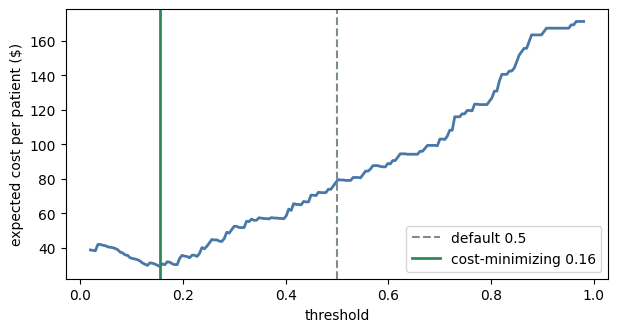

cost at 0.50 : $79.53 per patient
cost at 0.16 : $29.18 per patient
rule of thumb threshold = cost_FP/(cost_FP+cost_FN) = 0.11

At the chosen threshold: flag 185 of 257 patients; 46% of those flagged have diabetes; we catch 97% of real cases.


In [7]:
COST_MISS, COST_FALSE_ALARM = 500, 60
thresholds = np.linspace(0.02, 0.98, 200)
costs = [(((p_hat < t) & (yte == 1)).sum()*COST_MISS +
          ((p_hat >= t) & (yte == 0)).sum()*COST_FALSE_ALARM)/len(yte) for t in thresholds]
best = thresholds[int(np.argmin(costs))]

plt.plot(thresholds, costs, color="#4878a8", lw=2)
plt.axvline(0.5, ls="--", color="#7f8c8d", label="default 0.5")
plt.axvline(best, color="#2e8b57", lw=2, label=f"cost-minimizing {best:.2f}")
plt.xlabel("threshold"); plt.ylabel("expected cost per patient ($)"); plt.legend(); plt.show()

cost_at = lambda t: (((p_hat < t) & (yte == 1)).sum()*COST_MISS +
                     ((p_hat >= t) & (yte == 0)).sum()*COST_FALSE_ALARM)/len(yte)
print(f"cost at 0.50 : ${cost_at(0.5):.2f} per patient")
print(f"cost at {best:.2f} : ${cost_at(best):.2f} per patient")
print(f"rule of thumb threshold = cost_FP/(cost_FP+cost_FN) = "
      f"{COST_FALSE_ALARM/(COST_FALSE_ALARM+COST_MISS):.2f}")

tn, fp, fn, tp = confusion_matrix(yte, (p_hat >= best).astype(int)).ravel()
print(f"\nAt the chosen threshold: flag {tp+fp} of {len(yte)} patients; "
      f"{tp/(tp+fp):.0%} of those flagged have diabetes; we catch {tp/(tp+fn):.0%} of real cases.")

## 6. Is a predicted 30% really 30%?



   predicted     actual     n
        0.06       0.05    42
        0.15       0.12    51
        0.25       0.32    38
        0.35       0.18    28
        0.44       0.54    24
        0.56       0.38    16
        0.65       0.57    14
        0.74       0.68    19
        0.84       0.90    21


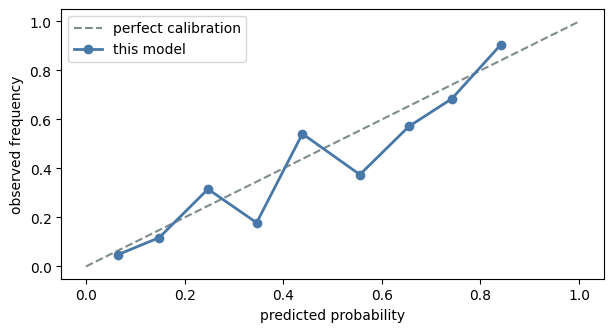

In [8]:
bins = np.linspace(0, 1, 11)
idx = np.digitize(p_hat, bins) - 1
print(f"{'predicted':>12} {'actual':>10} {'n':>5}")
xs, ys = [], []
for b in range(10):
    m = idx == b
    if m.sum() >= 8:
        xs.append(p_hat[m].mean()); ys.append(yte[m].mean())
        print(f"{p_hat[m].mean():>12.2f} {yte[m].mean():>10.2f} {m.sum():>5}")

plt.plot([0, 1], [0, 1], "--", color="#7f8c8d", label="perfect calibration")
plt.plot(xs, ys, "o-", color="#4878a8", lw=2, label="this model")
plt.xlabel("predicted probability"); plt.ylabel("observed frequency"); plt.legend(); plt.show()

If these points sit near the diagonal you may multiply the probabilities by dollars. If they do not, the model may still *rank* well, but any expected-cost calculation built on its numbers is fiction.